## Telecom Customer Churn Prediction

##### Customer churn is defined as when customers or subscribers discontinue doing business with a firm or service.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("telco_churn.csv")

### 1) Data Exploration and cleaning

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Handling missing values

In [12]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df = df.drop(columns=['customerID'])

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### 2) Data preprocessing

In [19]:
df["OnlineSecurity"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

#### Label Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder
df_cleaned = df.copy()
cols_to_encode = [
    "gender", "PhoneService", "Partner", "Dependents", "MultipleLines",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "PaperlessBilling", "Churn"
]
label_encode = LabelEncoder()
for col in cols_to_encode:
    df_cleaned[col] = label_encode.fit_transform(df_cleaned[col])
print(df_cleaned[cols_to_encode].head())

   gender  PhoneService  Partner  Dependents  MultipleLines  OnlineSecurity  \
0       0             0        1           0              1               0   
1       1             1        0           0              0               2   
2       1             1        0           0              0               2   
3       1             0        0           0              1               2   
4       0             1        0           0              0               0   

   OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  \
0             2                 0            0            0                0   
1             0                 2            0            0                0   
2             2                 0            0            0                0   
3             0                 2            2            0                0   
4             0                 0            0            0                0   

   PaperlessBilling  Churn  
0              

In [22]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


#### Removing Duplicates

In [24]:
df_cleaned.duplicated().sum()

22

In [25]:
df_cleaned = df_cleaned.drop_duplicates()

In [26]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['Contract', 'PaymentMethod', 'InternetService'], drop_first=True,dtype=int)

In [27]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7021 non-null   int64  
 1   SeniorCitizen                          7021 non-null   int64  
 2   Partner                                7021 non-null   int64  
 3   Dependents                             7021 non-null   int64  
 4   tenure                                 7021 non-null   int64  
 5   PhoneService                           7021 non-null   int64  
 6   MultipleLines                          7021 non-null   int64  
 7   OnlineSecurity                         7021 non-null   int64  
 8   OnlineBackup                           7021 non-null   int64  
 9   DeviceProtection                       7021 non-null   int64  
 10  TechSupport                            7021 non-null   int64  
 11  Streaming

In [28]:
df_cleaned.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,1,0,2,0,...,29.85,29.85,0,0,0,0,1,0,0,0
1,1,0,0,0,34,1,0,2,0,2,...,56.95,1889.50,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,0,2,2,0,...,53.85,108.15,1,0,0,0,0,1,0,0
3,1,0,0,0,45,0,1,2,0,2,...,42.30,1840.75,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,0,1,0,1,0


In [29]:

correlation_matrix = df_cleaned[["MonthlyCharges", "TotalCharges", "tenure", "Churn"]].corr()
print(correlation_matrix)

                MonthlyCharges  TotalCharges    tenure     Churn
MonthlyCharges        1.000000      0.650341  0.245251  0.194508
TotalCharges          0.650341      1.000000  0.824875 -0.197911
tenure                0.245251      0.824875  1.000000 -0.351508
Churn                 0.194508     -0.197911 -0.351508  1.000000


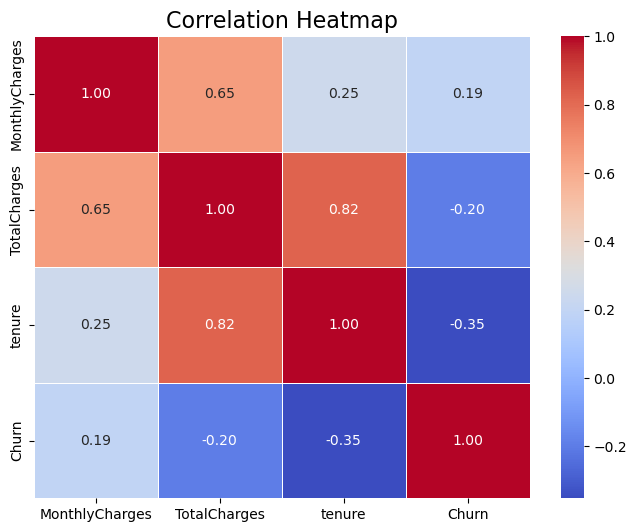

In [30]:
#  correlation matrix
corr_matrix = df_cleaned[["MonthlyCharges", "TotalCharges", "tenure", "Churn"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

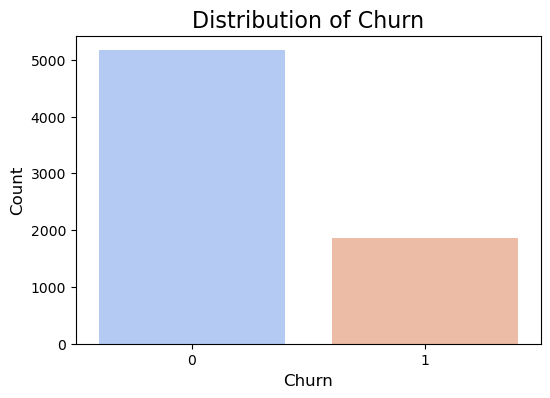

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x='Churn', palette='coolwarm')
plt.title('Distribution of Churn', fontsize=16)
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

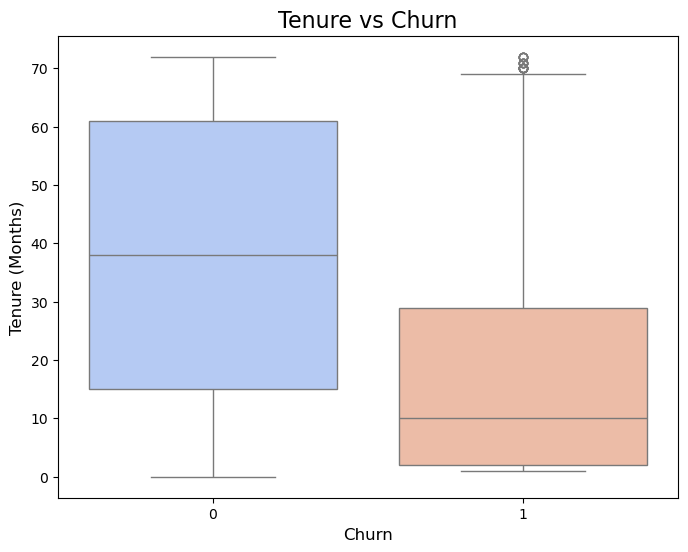

In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=df_cleaned, palette='coolwarm')
plt.title('Tenure vs Churn', fontsize=16)
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)
plt.show()

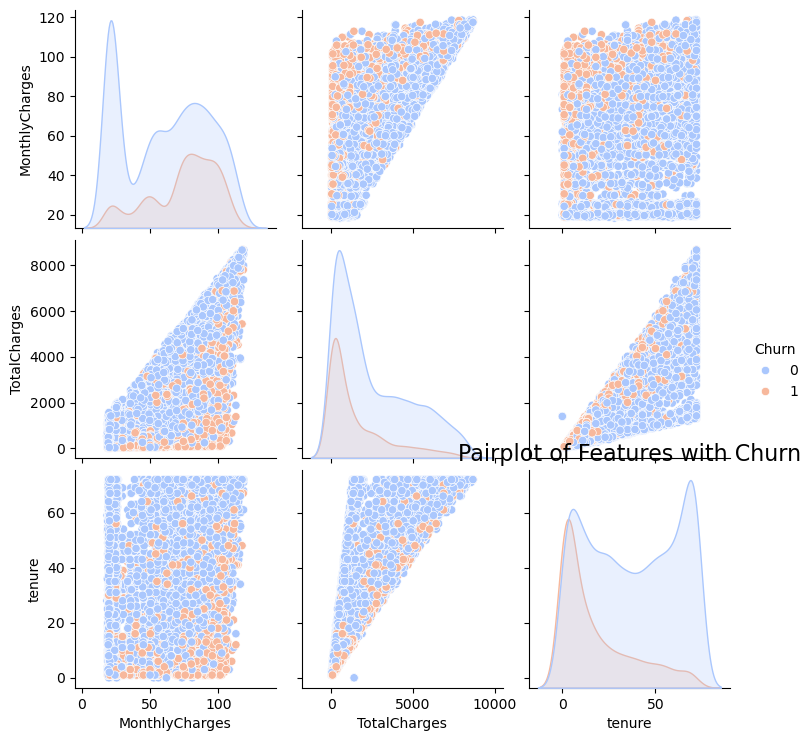

In [33]:
sns.pairplot(df_cleaned[["MonthlyCharges", "TotalCharges", "tenure", "Churn"]], hue="Churn", palette='coolwarm')
plt.title('Pairplot of Features with Churn', fontsize=16)
plt.show()

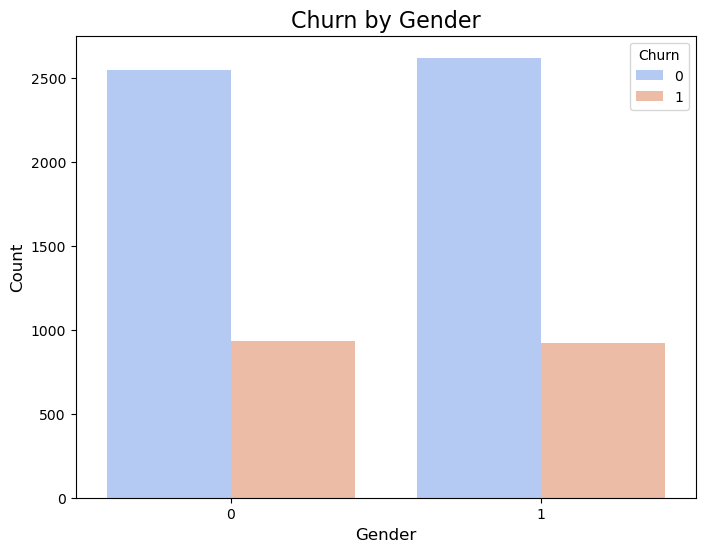

In [34]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='gender', hue='Churn', palette='coolwarm')
plt.title('Churn by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

#### Normalization

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_cleaned[['MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(df_cleaned[['MonthlyCharges', 'TotalCharges']])

In [37]:
df_cleaned.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,1,0,2,0,...,0.115423,0.001275,0,0,0,0,1,0,0,0
1,1,0,0,0,34,1,0,2,0,2,...,0.385075,0.215867,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,0,2,2,0,...,0.354229,0.010310,1,0,0,0,0,1,0,0
3,1,0,0,0,45,0,1,2,0,2,...,0.239303,0.210241,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,0.521891,0.015330,1,0,0,0,1,0,1,0


### 3) Feature Engineering + Splitting the data in Training and Testing

In [39]:
X = df_cleaned.drop("Churn",axis=1)
y = df_cleaned['Churn']

In [40]:
y.value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

In [41]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No'],
      dtype='object')

### Handling Imbalanced data using Resampling - Smote

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
from imblearn.over_sampling import SMOTE

In [45]:
print("Before undersampling:",y.value_counts())

Before undersampling: Churn
0    5164
1    1857
Name: count, dtype: int64


In [46]:
smote=SMOTE()

In [47]:
X_over,y_over=smote.fit_resample(X_train,y_train)

In [48]:
print("After smote:",y_over.count())

After smote: 8222


In [49]:
y_over.value_counts()

Churn
1    4111
0    4111
Name: count, dtype: int64

#### Forward Feature Selection

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def forward_feature_selection_knn(X_over, y_over, k=5, significance_level=0.05):
    selected_features = []
    remaining_features = list(X_over.columns)
    best_accuracy = 0

    while remaining_features:
        feature_accuracies = {}

        for feature in remaining_features:
            # Add the feature to the current model
            current_features = selected_features + [feature]
            X_model = X_over[current_features]

            # Fit KNN model
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_model, y_over)
            y_pred = knn.predict(X_model)

            # Evaluate the model (accuracy score)
            accuracy = accuracy_score(y_over, y_pred)
            feature_accuracies[feature] = accuracy

        # Find the feature with the best accuracy
        best_feature = max(feature_accuracies, key=feature_accuracies.get)
        best_accuracy = feature_accuracies[best_feature]

        # Add feature to the selected list and remove it from remaining features
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)

        print(f"Selected Feature: {best_feature}, Accuracy: {best_accuracy:.4f}")

    return selected_features

# Use the function on your data
selected_features_knn = forward_feature_selection_knn(X_train, y_train)
print("\nFinal Selected Features:", selected_features_knn)

Selected Feature: TotalCharges, Accuracy: 0.7847
Selected Feature: tenure, Accuracy: 0.8358
Selected Feature: Contract_One year, Accuracy: 0.8390
Selected Feature: TechSupport, Accuracy: 0.8415
Selected Feature: SeniorCitizen, Accuracy: 0.8456
Selected Feature: Contract_Two year, Accuracy: 0.8454
Selected Feature: StreamingTV, Accuracy: 0.8454
Selected Feature: OnlineSecurity, Accuracy: 0.8467
Selected Feature: PaymentMethod_Credit card (automatic), Accuracy: 0.8483
Selected Feature: InternetService_Fiber optic, Accuracy: 0.8488
Selected Feature: InternetService_No, Accuracy: 0.8486
Selected Feature: OnlineBackup, Accuracy: 0.8474
Selected Feature: PhoneService, Accuracy: 0.8478
Selected Feature: PaymentMethod_Electronic check, Accuracy: 0.8483
Selected Feature: MonthlyCharges, Accuracy: 0.8458
Selected Feature: Dependents, Accuracy: 0.8454
Selected Feature: Partner, Accuracy: 0.8437
Selected Feature: MultipleLines, Accuracy: 0.8408
Selected Feature: DeviceProtection, Accuracy: 0.8422


### 4) Implementing Ml Algorithm

#### A) K Nearest Neighbors

In [54]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')
knn.fit(X_over, y_over)

KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7188612099644128
Confusion Matrix:
 [[782 271]
 [124 228]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.74      0.80      1053
           1       0.46      0.65      0.54       352

    accuracy                           0.72      1405
   macro avg       0.66      0.70      0.67      1405
weighted avg       0.76      0.72      0.73      1405



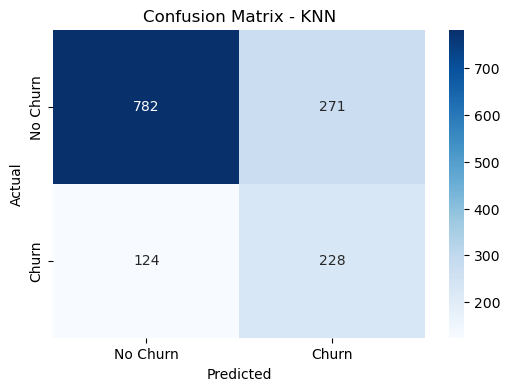

In [56]:
# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Hyper parameter Tuning - GridSearchCV

#### Finding the best paramameter to improve the model

In [59]:
from sklearn.model_selection import GridSearchCV

In [60]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_over, y_over)
print("Best Parameters:", grid_search.best_params_)
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


#### B) Decision Tree

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [63]:
dt= DecisionTreeClassifier(random_state=42)

In [64]:
dt.fit(X_over,y_over)

DecisionTreeClassifier(random_state=42)

In [65]:
y_pred_dt=dt.predict(X_test)

In [66]:
acc_dt=accuracy_score(y_test,y_pred_dt)
print("Accuracy score: ",acc_dt)
cm_dt=confusion_matrix(y_test,y_pred_dt)
print("Confusion Matrix:\n ",cm_dt)
cs_dt=classification_report(y_test,y_pred_dt)
print("Classification report:\n ",cs_dt)

Accuracy score:  0.7309608540925266
Confusion Matrix:
  [[824 229]
 [149 203]]
Classification report:
                precision    recall  f1-score   support

           0       0.85      0.78      0.81      1053
           1       0.47      0.58      0.52       352

    accuracy                           0.73      1405
   macro avg       0.66      0.68      0.67      1405
weighted avg       0.75      0.73      0.74      1405



#### Hyper parameter Tuning - GridSearchCV

In [68]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dt,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_over, y_over)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=1)

In [69]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score (Cross-Validated Accuracy):", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Score (Cross-Validated Accuracy): 0.7958033264556017


#### Decision tree with best parameter

In [71]:
best_dt_model = grid_search.best_estimator_
y_pred_best_dt = best_dt_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_best_dt))

Test Accuracy: 0.7274021352313167
Confusion Matrix:
 [[771 282]
 [101 251]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.73      0.80      1053
           1       0.47      0.71      0.57       352

    accuracy                           0.73      1405
   macro avg       0.68      0.72      0.68      1405
weighted avg       0.78      0.73      0.74      1405



#### C) Random Forest

In [73]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(random_state=42)
rf.fit(X_over,y_over)
y_pred_rf= rf.predict(X_test)

In [74]:
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy Score: 0.7658362989323844
Confusion Matrix:
 [[858 195]
 [134 218]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.81      0.84      1053
           1       0.53      0.62      0.57       352

    accuracy                           0.77      1405
   macro avg       0.70      0.72      0.70      1405
weighted avg       0.78      0.77      0.77      1405



### Hyper parameter Tuning - GridSearchCV

In [76]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}
grid_rf = GridSearchCV(estimator=rf,
                       param_grid=param_grid,
                       cv=5,
                       scoring='accuracy',
                       n_jobs=-1,
                       verbose=1)

grid_rf.fit(X_over, y_over)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [77]:
print("Best Parameters:", grid_rf.best_params_)
print("Best Cross-Validated Accuracy:", grid_rf.best_score_)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validated Accuracy: 0.849198929144573


#### Random forest with best parameter

In [79]:
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_best_rf))

Test Accuracy: 0.7693950177935943
Confusion Matrix:
 [[861 192]
 [132 220]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.82      0.84      1053
           1       0.53      0.62      0.58       352

    accuracy                           0.77      1405
   macro avg       0.70      0.72      0.71      1405
weighted avg       0.78      0.77      0.78      1405



#### D) Support vector Machine (SVM)

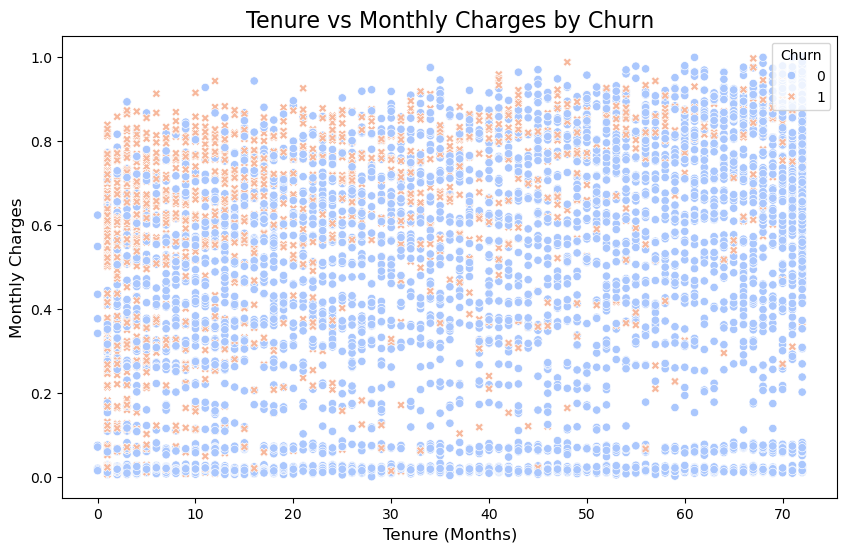

In [81]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='tenure', y='MonthlyCharges', hue='Churn', palette='coolwarm', style='Churn', markers=["o", "X"])
plt.title('Tenure vs Monthly Charges by Churn', fontsize=16)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Monthly Charges', fontsize=12)
plt.legend(title='Churn', loc='upper right')
plt.show()

In [82]:
from sklearn.svm import SVC

In [83]:
svm_model = SVC(kernel="rbf",random_state=42)
svm_model.fit(X_over,y_over)
y_pred_svm=svm_model.predict(X_test)

In [84]:
print("Accuracy Score:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

Accuracy Score: 0.7487544483985765
Confusion Matrix:
 [[785 268]
 [ 85 267]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.75      0.82      1053
           1       0.50      0.76      0.60       352

    accuracy                           0.75      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.75      0.76      1405



In [85]:
from mlxtend.plotting import plot_decision_regions

In [86]:

X_train_2d = X_over[["TotalCharges", "tenure"]]   
X_test_2d = X_test[["TotalCharges", "tenure"]]
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
svm_model_2d = SVC(random_state=42)
svm_model_2d.fit(X_train_2d, y_over)

SVC(random_state=42)

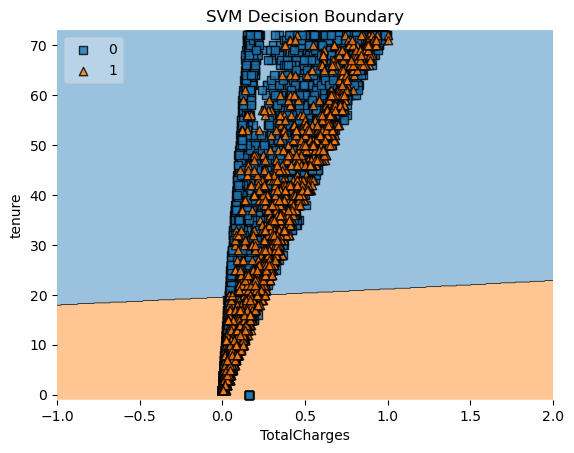

In [87]:
plot_decision_regions(X_train_2d.values, y_over.values, clf=svm_model_2d, legend=2)

plt.xlabel('TotalCharges')
plt.ylabel('tenure')
plt.title('SVM Decision Boundary')
plt.show()

#### E) Logistic regression

In [89]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_over,y_over)

LogisticRegression()

In [90]:
y_pred=model.predict(X_test)

In [91]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.7423487544483985
Confusion Matrix:
 [[784 269]
 [ 93 259]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.74      0.81      1053
           1       0.49      0.74      0.59       352

    accuracy                           0.74      1405
   macro avg       0.69      0.74      0.70      1405
weighted avg       0.79      0.74      0.76      1405



In [94]:
X_over

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,0,0,4,1,0,0,0,0,...,1,0.605970,0.034439,0,0,0,1,0,1,0
1,1,1,0,0,33,1,2,0,2,2,...,1,0.652736,0.311274,0,0,1,0,0,1,0
2,0,0,1,1,4,1,0,1,1,1,...,0,0.020896,0.006641,0,0,0,0,1,0,1
3,1,0,0,0,9,1,0,1,1,1,...,1,0.016418,0.016824,1,0,0,1,0,0,1
4,0,0,1,1,29,1,2,1,1,1,...,0,0.078109,0.077746,0,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8217,1,1,1,0,36,1,2,0,0,0,...,1,0.658222,0.349864,0,0,0,0,0,1,0
8218,1,0,0,0,7,0,1,2,0,0,...,1,0.134162,0.025892,0,0,0,1,0,0,0
8219,0,0,1,1,16,1,1,0,0,2,...,0,0.701864,0.164809,0,0,0,0,0,1,0
8220,1,0,1,0,5,1,2,0,2,0,...,1,0.605484,0.045317,0,0,0,1,0,1,0


### Conclusion:

##### Customer churn is definitely bad to a firm ’s profitability. Various strategies can be implemented to eliminate customer churn. The best way to avoid customer churn is for a company to truly know its customers. This includes identifying customers who are at risk of churning and working to improve their satisfaction. Improving customer service is, of course, at the top of the priority for tackling this issue. Building customer loyalty through relevant experiences and specialized service is another strategy to reduce customer churn. Some firms survey customers who have already churned to understand their reasons for leaving in order to adopt a proactive approach to avoiding future customer churn.